### 경사 하강법
- 옵티마이저(Optimizer) 또는 최적화 알고리즘
    - 비용 함수를 최소화하는 매개변수인 w와 b를 찾는 알고리즘
    - 옵티마이저를 통해 적절한 w와 b를 찾는 과정을 머신러닝에서 훈련(training) 또는 학습(learning)이라고 함.
- 경사 하강법(Gradient Descent)
    - 가장 기본적인 최적화 알고리즘
    - $H(x) = wx$로 가정
    - $w$와 $cost$의 상관 관계  
    <img src="img/o.png" alt="a" style="width:800px;" />
    1. 비용 함수를 미분하여 현재 w에서 접선의 기울기를 구한다.
    2. 접선의 기울기가 낮은 방향으로 w의 값을 변경하고 다시 미분한다.
    3. 이 과정을 접선의 기울기가 0이 되도록 w의 값이 변할 때까지 반복한다.  
        $cost(w,b) = \frac{1}{n} \sum_{i=1}^{n} [ y_i - H(x_i) ]^2$ 에서  
        $w := w - \alpha \frac{\partial}{\partial w}cost(w)$  
        $\alpha$는 학습률(learning rate)이라고 불리는 하이퍼파라미터로, w의 값을 얼마나 크게 변경할지를 결정하는 값. 0과 1사이의 값을 가진다. 너무 크면 $cost$가 발산할 수 있고, 너무 작으면 학습이 너무 오래 걸릴 수 있다.  
        접선의 기울기가 음수이면 $\alpha\frac{\partial}{\partial w}cost(w) < 0$, $w := w - (-)$ 에서 증가, 양수이면 감소됨.

In [ ]:
# python version: 3.9.25
# tensorflow version: 2.12

import tensorflow as tf

# f(w) = 2w² + 5
w = tf.Variable(2.) # 초기값 2.0인 변수 생성

def f(w):
    y = w**2
    z = 2*y + 5
    return z

with tf.GradientTape() as tape: # z = f(x)의 계산경로(그래프) 기록 시작
    z = f(w)

# f(x) 를 w에 대하여 미분
gradients = tape.gradient(z, [w])
print(gradients)

[<tf.Tensor: shape=(), dtype=float32, numpy=8.0>]


In [2]:
import tensorflow as tf

w = tf.Variable(4.0)
b = tf.Variable(1.0)

@tf.function # 일반 함수를 TensorFlow의 고성능 계산 그래프 형태로 바꿈(속도 향상, 최적화(미리 최적의 경로를 설계해 둠))
def hypothesis(x):
    return w*x + b

x_test = [3.5, 5, 5.5, 6]
print(hypothesis(x_test).numpy())

[15. 21. 23. 25.]


In [7]:
import tensorflow as tf

@tf.function
def add_one(x):
    print("나 지금 파이썬 코드로 설계도 그리는 중이야!") # (A)
    return x + 1 # (B)

# 첫 번째 실행
print("--- 1회 실행 ---")
print(add_one(tf.constant(1)).numpy())

# 두 번째 실행
print("--- 2회 실행 ---")
print(add_one(tf.constant(2)).numpy())

--- 1회 실행 ---
나 지금 파이썬 코드로 설계도 그리는 중이야!
2
--- 2회 실행 ---
3


In [ ]:
# 자동 미분을 이용한 선형 회귀 구현

import tensorflow as tf

w = tf.Variable(4.0)
b = tf.Variable(1.0)

@tf.function
def hypothesis(x):
    return w*x + b

# 실제값 y와 예측값 y_pred 를 받아서 MSE 계산
@tf.function
def mse_loss(y, y_pred):
    # reduce_mean: 합의 평균
    return tf.reduce_mean(tf.square(y - y_pred))

x = [1,2,3,4,5,6,7,8,9] # study_hour
y = [11, 22, 33, 44, 53, 66, 77, 87, 95] # score


optimizer = tf.optimizers.SGD(0.01) # 경사하강법
for i in range(301):
    with tf.GradientTape() as tape:
        y_pred = hypothesis(x)

        cost = mse_loss(y_pred, y)

    gradients = tape.gradient(cost, [w, b])

    optimizer.apply_gradients(zip(gradients, [w, b]))

    if i % 10 == 0:
        print(f"epoch: {i:3} | w의 값: {w.numpy():5.4f} | b의 값: {b.numpy():5.4f} | cost: {cost:5.6f}")


epoch:   0 | w의 값: 8.2133 | b의 값: 1.6644 | cost: 1402.555542
epoch:  10 | w의 값: 10.4971 | b의 값: 1.9769 | cost: 1.351182
epoch:  20 | w의 값: 10.5047 | b의 값: 1.9297 | cost: 1.328165
epoch:  30 | w의 값: 10.5119 | b의 값: 1.8844 | cost: 1.306967
epoch:  40 | w의 값: 10.5188 | b의 값: 1.8409 | cost: 1.287436
epoch:  50 | w의 값: 10.5254 | b의 값: 1.7991 | cost: 1.269459
epoch:  60 | w의 값: 10.5318 | b의 값: 1.7591 | cost: 1.252898
epoch:  70 | w의 값: 10.5379 | b의 값: 1.7206 | cost: 1.237644
epoch:  80 | w의 값: 10.5438 | b의 값: 1.6837 | cost: 1.223598
epoch:  90 | w의 값: 10.5494 | b의 값: 1.6483 | cost: 1.210658
epoch: 100 | w의 값: 10.5548 | b의 값: 1.6143 | cost: 1.198740
epoch: 110 | w의 값: 10.5600 | b의 값: 1.5817 | cost: 1.187767
epoch: 120 | w의 값: 10.5650 | b의 값: 1.5504 | cost: 1.177665
epoch: 130 | w의 값: 10.5697 | b의 값: 1.5204 | cost: 1.168354
epoch: 140 | w의 값: 10.5743 | b의 값: 1.4916 | cost: 1.159782
epoch: 150 | w의 값: 10.5787 | b의 값: 1.4639 | cost: 1.151890
epoch: 160 | w의 값: 10.5829 | b의 값: 1.4373 | cost: 1.14

c:\Users\0627j\anaconda3\envs\DL\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Epoch 1/300
1/1 [==============================] - 0s 167ms/step - loss: 3611.0603 - mse: 3611.0603
Epoch 2/300
1/1 [==============================] - 0s 3ms/step - loss: 445.3754 - mse: 445.3754
Epoch 3/300
1/1 [==============================] - 0s 2ms/step - loss: 55.8606 - mse: 55.8606
Epoch 4/300
1/1 [==============================] - 0s 4ms/step - loss: 7.9326 - mse: 7.9326
Epoch 5/300
1/1 [==============================] - 0s 0s/step - loss: 2.0343 - mse: 2.0343
Epoch 6/300
1/1 [==============================] - 0s 8ms/step - loss: 1.3075 - mse: 1.3075
Epoch 7/300
1/1 [==============================] - 0s 0s/step - loss: 1.2171 - mse: 1.2171
Epoch 8/300
1/1 [==============================] - 0s 10ms/step - loss: 1.2049 - mse: 1.2049
Epoch 9/300
1/1 [==============================] - 0s 0s/step - loss: 1.2024 - mse: 1.2024
Epoch 10/300
1/1 [==============================] - 0s 8ms/step - loss: 1.2010 - mse: 1.2010
Epoch 11/300
1/1 [==============================] - 0s 7ms/step - l

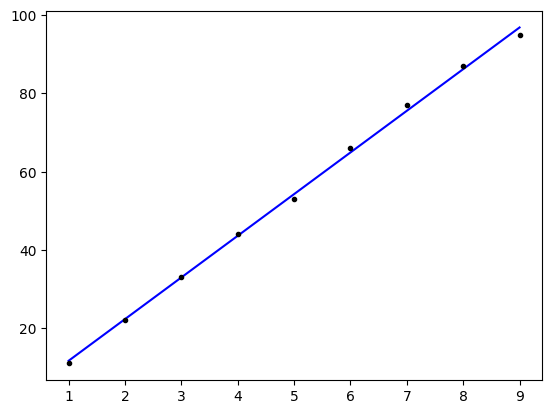

In [ ]:
# 케라스로 구현하는 선형회귀

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import optimizers

x = np.array([1,2,3,4,5,6,7,8,9]) # study_hour
y = np.array([11, 22, 33, 44, 53, 66, 77, 87, 95]) # score

model = Sequential()

#출력 y의 차원(arg0)은 1. 입력 x의 차원(input_dim)은 1
# 선형회귀이므로 activation은 'linear'
model.add(Dense(1, input_dim=1, activation='linear'))

# sgd는 경사하강법을 의미. 학습률(learning rate, lr)은 0.01
sgd = optimizers.SGD(learning_rate=0.01)

# 손실 함수(Loss function)은 평균제곱오차 mse 사용, 확인하고 싶은 수치는 metrics=['mse']
model.compile(optimizer=sgd, loss='mse', metrics=['mse'])

# 주어진 x와 y 데이터에 대해 오차를 최소화하는 작업을 300번 시도
model.fit(x, y, epochs=300)

# 그래프 그리기
plt.plot(x, model.predict(x), 'b', x, y, 'k.')

print(model.predict([9.5]))